In [1]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\BackUp_Dec_2025\Predictive_project\A_Z Handwritten Data.csv")

In [3]:
df.sample()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
300897,19,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


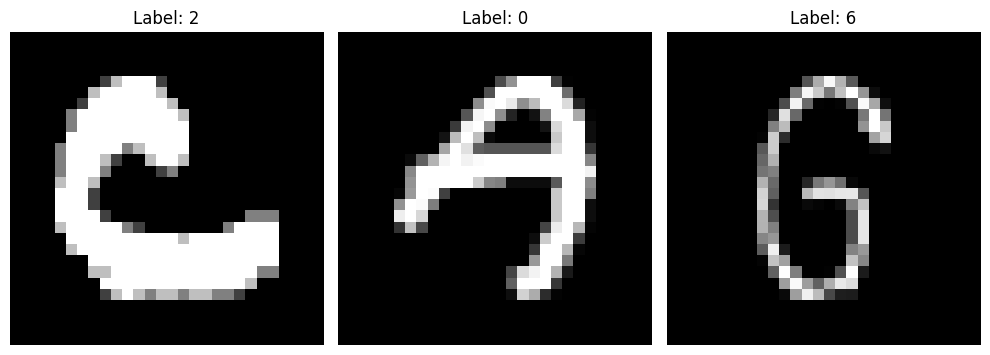

In [10]:

indices = [40600, 40, 70750]

plt.figure(figsize=(10, 4))

for j, i in enumerate(indices):
    img = pixels.iloc[i].values.reshape(28, 28)
    
    plt.subplot(1, 3, j+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels.iloc[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [12]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]
      

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.3,random_state=42)
lr = LogisticRegression()
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
acc_lr = lr.score(X_test,y_test)
print(acc_lr)

0.8785877298966304


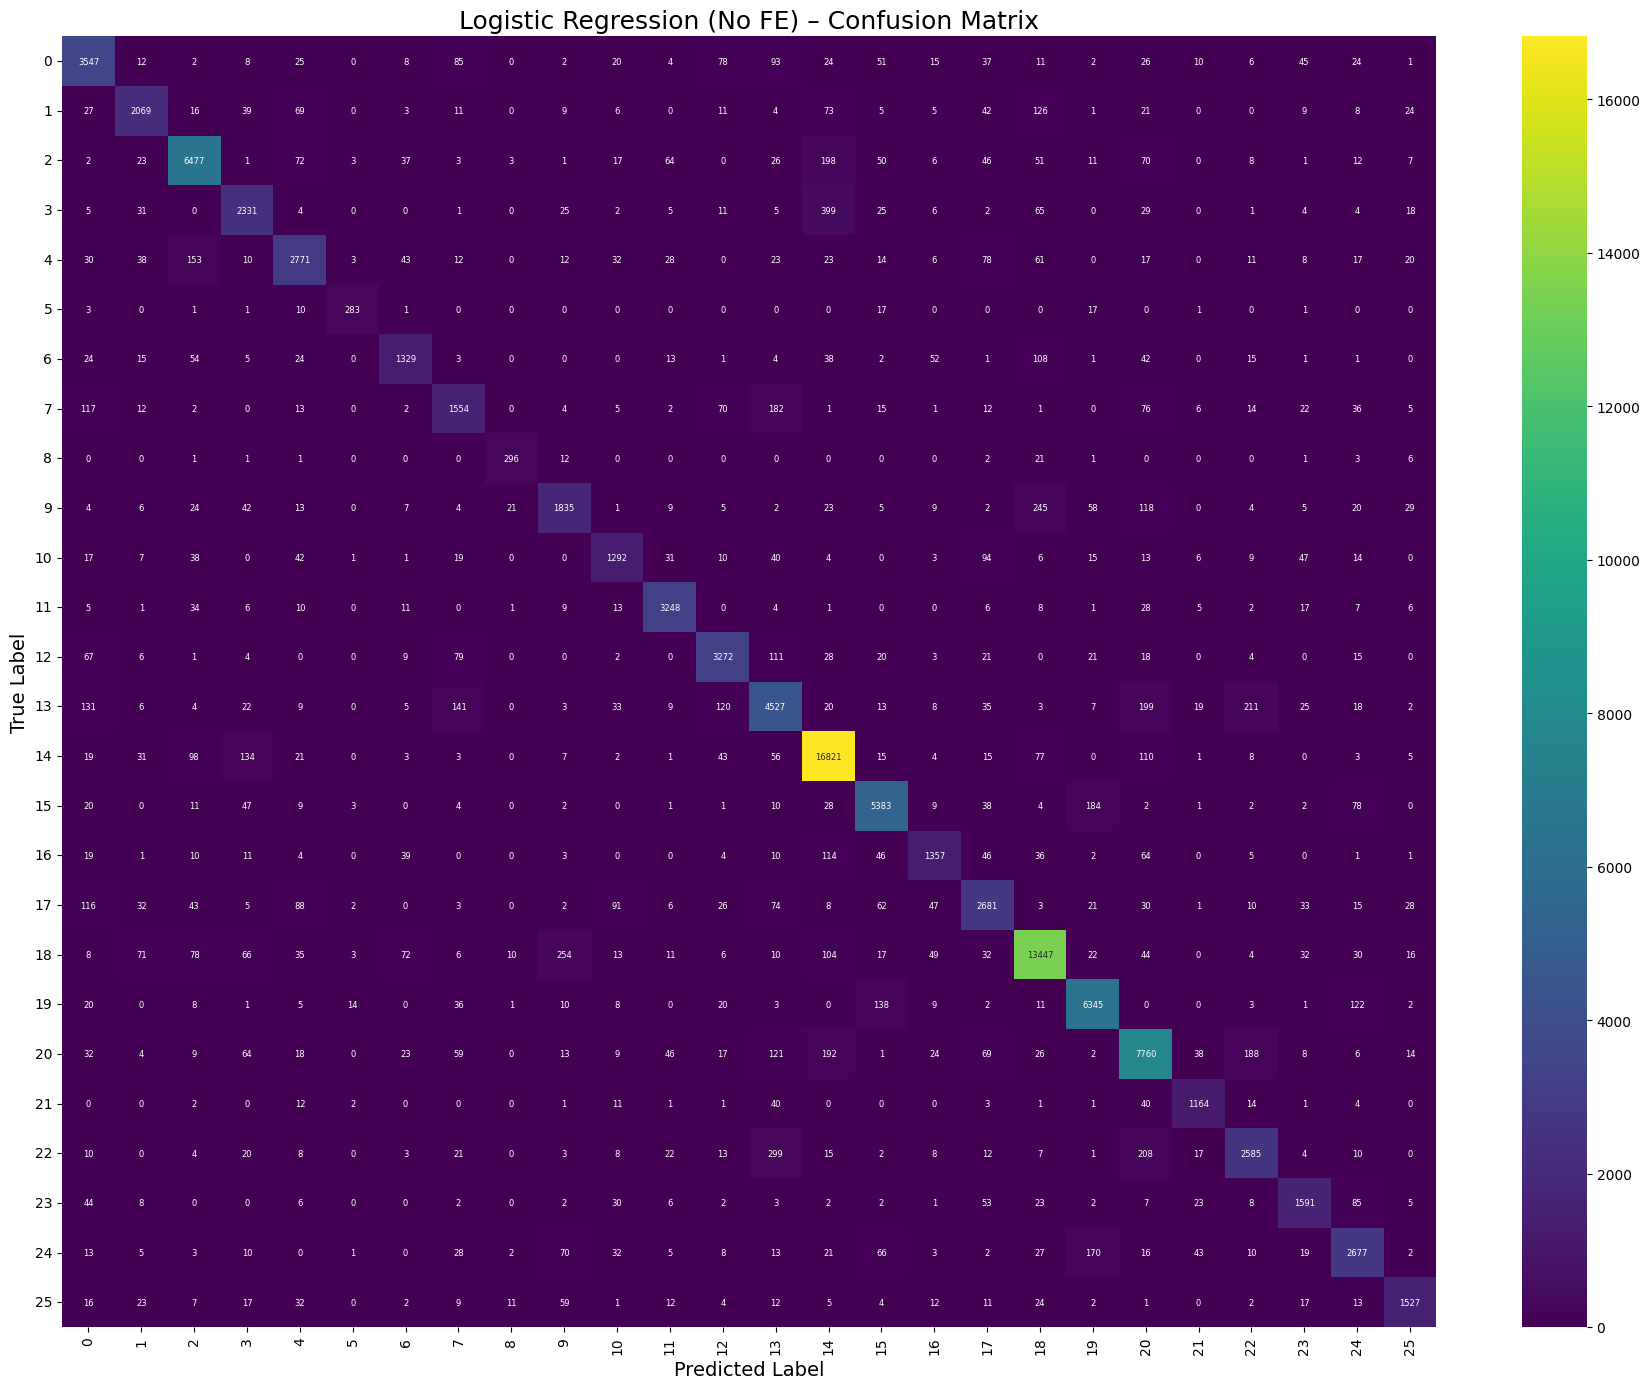

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 14))  # Bigger figure
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            annot_kws={"size": 6})  # Reduce text size

plt.title("Logistic Regression (No FE) – Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.xticks(fontsize=10, rotation=90)  # rotate predicted labels
plt.yticks(fontsize=10, rotation=0)   # keep true labels horizontal

plt.tight_layout()
plt.show()


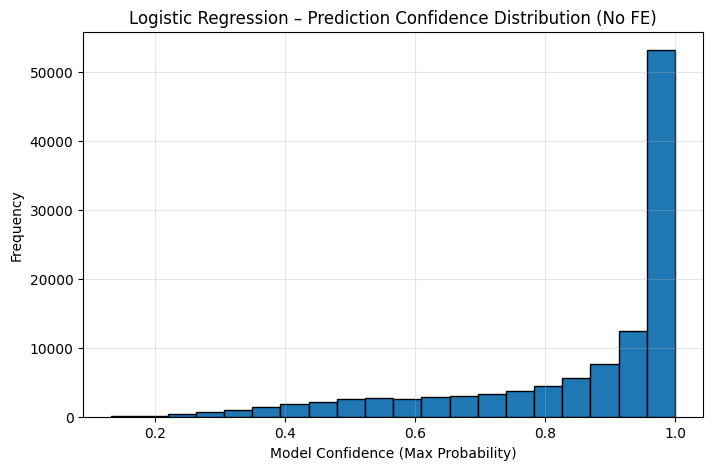

In [18]:
import matplotlib.pyplot as plt

# get predicted probabilities for each class
proba_lr = lr.predict_proba(X_test)

# take maximum probability per prediction (model confidence)
max_confidence = proba_lr.max(axis=1)

# plot the histogram
plt.figure(figsize=(8,5))
plt.hist(max_confidence, bins=20, edgecolor='black')
plt.title("Logistic Regression – Prediction Confidence Distribution (No FE)")
plt.xlabel("Model Confidence (Max Probability)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1️⃣ Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2️⃣ PCA
pca = PCA(n_components=100)  # try 50, 100, 150
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 3️⃣ Train LR
lr_fe = LogisticRegression(max_iter=2000)
lr_fe.fit(X_train_pca, y_train)

# 4️⃣ Evaluate
y_pred_fe = lr_fe.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred_fe)
print("Accuracy with Feature Engineering:", accuracy)


Accuracy with Feature Engineering: 0.8701928670515058


# Accuracy Fall but faster Because model is trained for only 100 features

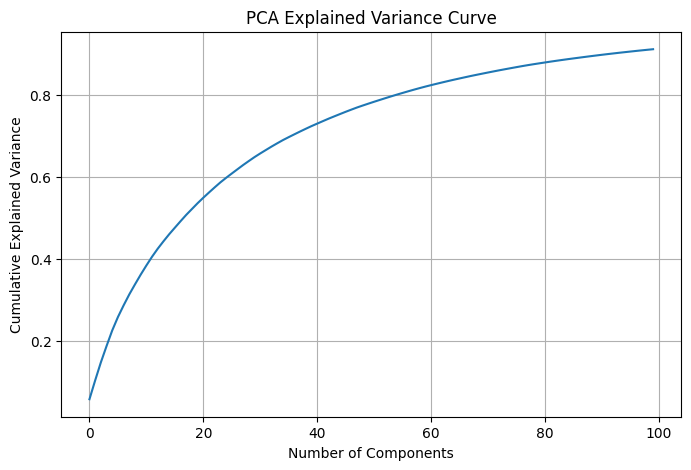

In [20]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve")
plt.grid(True)
plt.show()


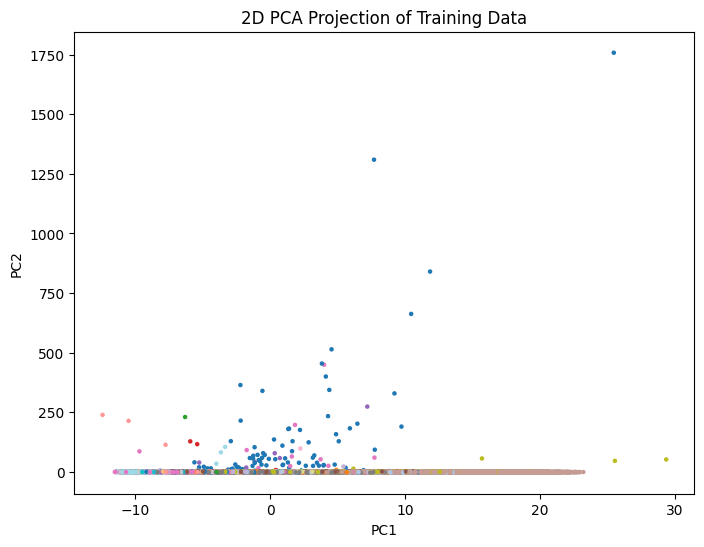

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, s=5, cmap="tab20")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection of Training Data")
plt.show()


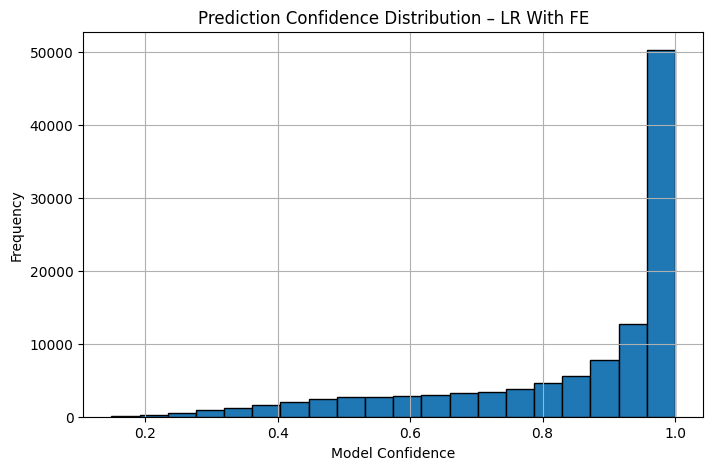

In [23]:
proba_fe = lr_fe.predict_proba(X_test_pca)
conf_fe = proba_fe.max(axis=1)

plt.figure(figsize=(8,5))
plt.hist(conf_fe, bins=20, edgecolor="black")
plt.title("Prediction Confidence Distribution – LR With FE")
plt.xlabel("Model Confidence")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


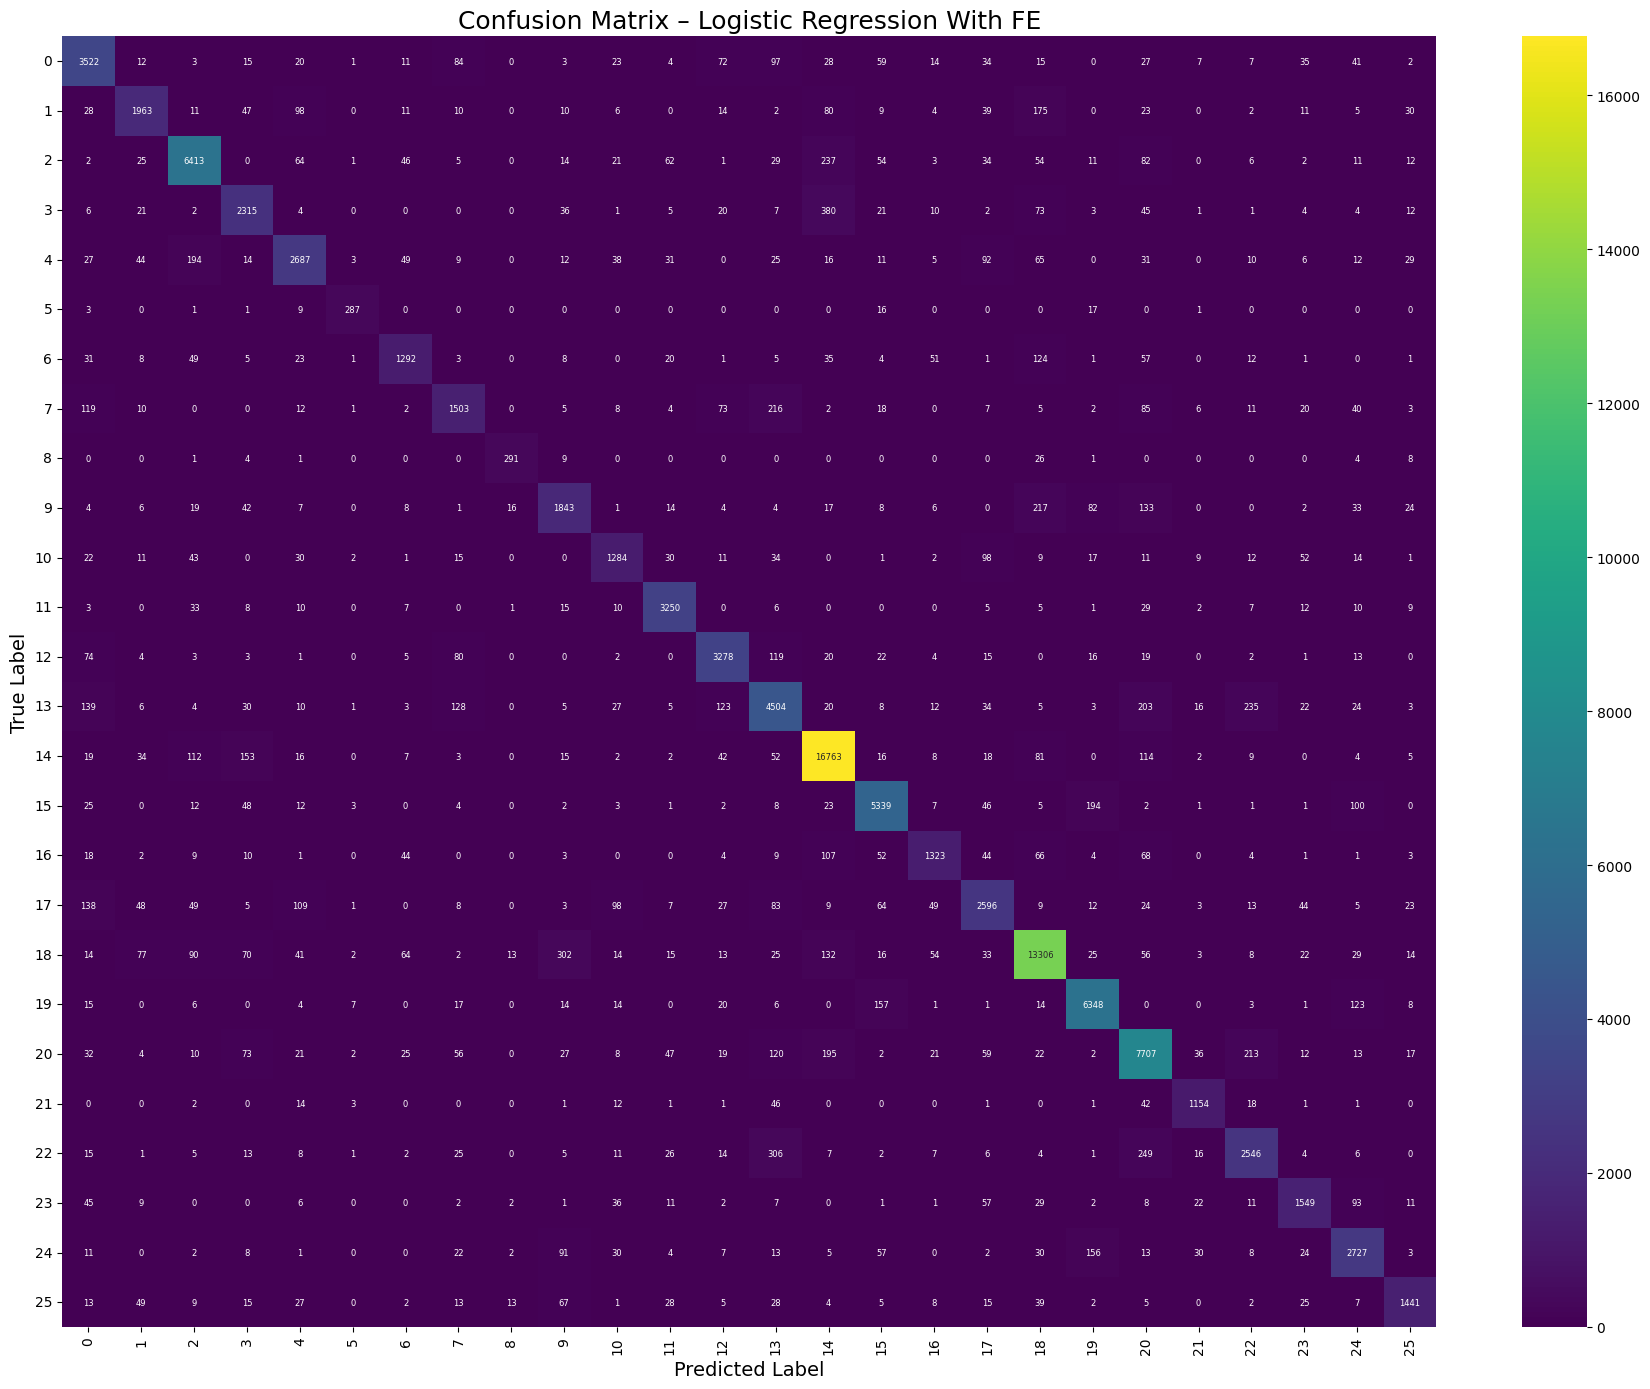

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_fe = confusion_matrix(y_test, y_pred_fe)

plt.figure(figsize=(18,14))
sns.heatmap(cm_fe,
            annot=True,        # show numbers
            fmt="d",           # integer format
            cmap="viridis",
            annot_kws={"size": 6})   # smaller text for readability

plt.title("Confusion Matrix – Logistic Regression With FE", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


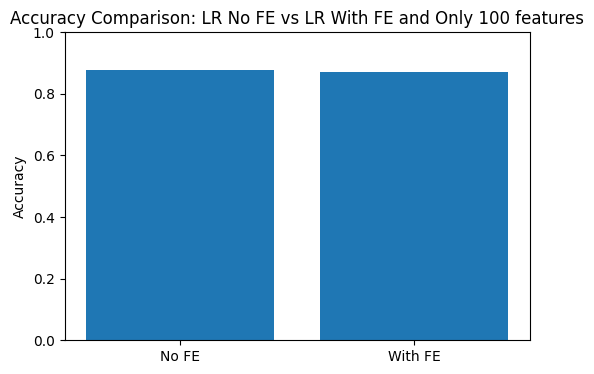

In [29]:
plt.figure(figsize=(6,4))
plt.bar(["No FE", "With FE"], [acc_lr, accuracy])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: LR No FE vs LR With FE and Only 100 features")
plt.ylim(0,1)
plt.show()
